# 04 Trend Analysis

This notebook analyzes child-level malnutrition progress over time.

Main goals:
- Check each child's first visit and latest visit
- Calculate MUAC improvement or deterioration
- Identify whether a child is improving, deteriorating, or stable
- Check movement between risk groups
- Save trend-ready output for the next analysis step

## 1. Import Libraries and Load Dataset

This notebook uses the clustered dataset generated from Notebook 03.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

DATA_PATH = Path("../data/clustered_data.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError("clustered_data.csv not found. Please run Notebook 03 first.")

df = pd.read_csv(DATA_PATH)

df["ID"] = df["ID"].astype(str)
df["GmpDate"] = pd.to_datetime(df["GmpDate"], errors="coerce")

df = df.sort_values(["ID", "GmpDate"]).reset_index(drop=True)

print("Dataset Shape:", df.shape)
print("Unique Children:", df["ID"].nunique())

df.head()

Dataset Shape: (6785, 15)
Unique Children: 3041


,ID,GmpDate,Name_Original,Name,DOB_Original,DOB,MUAC,Age,Age_Months,Age_Diff,Condition,Cluster_MUAC_Original,Cluster_Age_MUAC,Cluster,Cluster_Name
0,581415010001,2017-12-17,ff,ff,2017-12-17,2017-12-17,15.0,84.0,0.00,84.00,Good,1,0,0,Healthy
1,581415010001,2017-12-28,hdkdj,ff,2017-12-28,2017-12-17,15.0,84.0,0.36,83.64,Good,1,0,0,Healthy
2,581415010002,2017-12-17,rahim,gg,2017-12-17,2017-12-17,13.0,84.0,0.00,84.00,At Risk,0,1,1,Moderate Risk
3,581415010002,2017-12-28,ldjjd,gg,2017-12-28,2017-12-17,14.0,84.0,0.36,83.64,Good,0,0,1,Moderate Risk
4,581415010003,2017-12-28,ifjjfjk,ifjjfjk,2017-12-28,2017-12-28,13.0,84.0,0.00,84.00,At Risk,0,1,1,Moderate Risk


## 2. Select Required Columns

The dataset may contain different cluster column names depending on the previous notebook.
This section standardizes the column names for trend analysis.

In [2]:
# Standardize cluster label column
if "Cluster_Name" not in df.columns:
    if "Cluster_Label" in df.columns:
        df["Cluster_Name"] = df["Cluster_Label"]
    else:
        raise KeyError("Cluster_Name or Cluster_Label column not found. Please check Notebook 03 output.")

# Standardize cluster number column
if "Cluster" not in df.columns:
    if "Cluster_Final" in df.columns:
        df["Cluster"] = df["Cluster_Final"]
    elif "Cluster_MUAC_Only" in df.columns:
        df["Cluster"] = df["Cluster_MUAC_Only"]
    else:
        raise KeyError("Cluster / Cluster_Final / Cluster_MUAC_Only column not found.")

required_columns = [
    "ID",
    "GmpDate",
    "Name",
    "DOB",
    "MUAC",
    "Age_Months",
    "Condition",
    "Cluster",
    "Cluster_Name"
]

available_columns = [col for col in required_columns if col in df.columns]

df = df[available_columns].copy()

df.head()

,ID,GmpDate,Name,DOB,MUAC,Age_Months,Condition,Cluster,Cluster_Name
0,581415010001,2017-12-17,ff,2017-12-17,15.0,0.00,Good,0,Healthy
1,581415010001,2017-12-28,ff,2017-12-17,15.0,0.36,Good,0,Healthy
2,581415010002,2017-12-17,gg,2017-12-17,13.0,0.00,At Risk,1,Moderate Risk
3,581415010002,2017-12-28,gg,2017-12-17,14.0,0.36,Good,1,Moderate Risk
4,581415010003,2017-12-28,ifjjfjk,2017-12-28,13.0,0.00,At Risk,1,Moderate Risk


## 3. Visit Count Analysis

Trend analysis requires at least two visits per child.

Children with only one visit can be classified by current condition, but improvement/deterioration cannot be calculated for them.

In [3]:
visit_counts = df.groupby("ID").size()

print("Total Children:", df["ID"].nunique())
print("Children with only 1 visit:", (visit_counts == 1).sum())
print("Children with 2+ visits:", (visit_counts >= 2).sum())

visit_counts.describe()

Total Children: 3041
Children with only 1 visit: 1705
Children with 2+ visits: 1336


count    3041.000000
mean        2.231174
std         2.140500
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        16.000000
dtype: float64

## 4. Create Trend Dataset

Only children with two or more visits are selected for trend analysis.

In [4]:
multi_visit_ids = visit_counts[visit_counts >= 2].index

trend_df = df[df["ID"].isin(multi_visit_ids)].copy()
trend_df = trend_df.sort_values(["ID", "GmpDate"])

print("Trend Ready Records:", len(trend_df))
print("Trend Ready Children:", trend_df["ID"].nunique())

trend_df.head()

Trend Ready Records: 5080
Trend Ready Children: 1336


,ID,GmpDate,Name,DOB,MUAC,Age_Months,Condition,Cluster,Cluster_Name
0,581415010001,2017-12-17,ff,2017-12-17,15.0,0.00,Good,0,Healthy
1,581415010001,2017-12-28,ff,2017-12-17,15.0,0.36,Good,0,Healthy
2,581415010002,2017-12-17,gg,2017-12-17,13.0,0.00,At Risk,1,Moderate Risk
3,581415010002,2017-12-28,gg,2017-12-17,14.0,0.36,Good,1,Moderate Risk
5,581415010004,2017-12-18,hskkd,2017-12-18,13.0,0.00,At Risk,1,Moderate Risk


## 5. First Visit and Latest Visit Comparison

For each child:
- First visit = earliest GMP date
- Latest visit = most recent GMP date

In [5]:
first_visit = (
    trend_df
    .groupby("ID")
    .first()
    .reset_index()
)

last_visit = (
    trend_df
    .groupby("ID")
    .last()
    .reset_index()
)

comparison = first_visit.merge(
    last_visit,
    on="ID",
    suffixes=("_First", "_Last")
)

print("Comparison Shape:", comparison.shape)

comparison.head()

Comparison Shape: (1336, 17)


,ID,GmpDate_First,Name_First,DOB_First,MUAC_First,Age_Months_First,Condition_First,Cluster_First,Cluster_Name_First,GmpDate_Last,Name_Last,DOB_Last,MUAC_Last,Age_Months_Last,Condition_Last,Cluster_Last,Cluster_Name_Last
0,581415010001,2017-12-17,ff,2017-12-17,15.0,0.00,Good,0,Healthy,2017-12-28,ff,2017-12-17,15.0,0.36,Good,0,Healthy
1,581415010002,2017-12-17,gg,2017-12-17,13.0,0.00,At Risk,1,Moderate Risk,2017-12-28,gg,2017-12-17,14.0,0.36,Good,1,Moderate Risk
2,581415010004,2017-12-18,hskkd,2017-12-18,13.0,0.00,At Risk,1,Moderate Risk,2017-12-28,hskkd,2017-12-18,15.0,0.33,Good,0,Healthy
3,581415010035,2017-12-28,kffhj,2017-12-28,14.0,0.00,Good,1,Moderate Risk,2018-07-19,kffhj,2017-12-28,15.4,6.67,Good,0,Healthy
4,581494010009,2017-12-21,abc,2017-06-01,11.5,6.67,Moderate,1,Moderate Risk,2017-12-27,abc,2017-06-01,15.0,6.87,Good,0,Healthy


## 6. MUAC Change Calculation

MUAC change shows whether the child's nutrition measurement increased or decreased between first and latest visit.

Formula:

MUAC_Change = Latest MUAC - First MUAC

In [6]:
comparison["MUAC_Change"] = (
    comparison["MUAC_Last"] - comparison["MUAC_First"]
)

comparison["MUAC_Change_Percent"] = (
    (comparison["MUAC_Change"] / comparison["MUAC_First"]) * 100
).round(2)

comparison[
    [
        "ID",
        "MUAC_First",
        "MUAC_Last",
        "MUAC_Change",
        "MUAC_Change_Percent"
    ]
].head()

,ID,MUAC_First,MUAC_Last,MUAC_Change,MUAC_Change_Percent
0,581415010001,15.0,15.0,0.0,0.00
1,581415010002,13.0,14.0,1.0,7.69
2,581415010004,13.0,15.0,2.0,15.38
3,581415010035,14.0,15.4,1.4,10.00
4,581494010009,11.5,15.0,3.5,30.43


## 7. Trend Label

Trend is assigned using MUAC change.

- Improved: MUAC increased
- Deteriorated: MUAC decreased
- Stable: MUAC did not change

In [7]:
def get_trend(change):
    if change > 0:
        return "Improved"
    elif change < 0:
        return "Deteriorated"
    else:
        return "Stable"

comparison["Trend"] = comparison["MUAC_Change"].apply(get_trend)

comparison["Trend"].value_counts()

Trend
Improved        717
Deteriorated    349
Stable          270
Name: count, dtype: int64

## 8. Risk Group Transition

This section checks whether the child moved to a better or worse cluster group.

Risk score:
- Healthy = 0
- Moderate Risk = 1
- High Risk = 2

Lower score means better nutritional status.

In [8]:
risk_score_map = {
    "Healthy": 0,
    "Moderate Risk": 1,
    "High Risk": 2
}

comparison["Risk_Score_First"] = comparison["Cluster_Name_First"].map(risk_score_map)
comparison["Risk_Score_Last"] = comparison["Cluster_Name_Last"].map(risk_score_map)

comparison["Risk_Score_Change"] = (
    comparison["Risk_Score_Last"] - comparison["Risk_Score_First"]
)

def get_risk_transition(change):
    if change < 0:
        return "Moved to Better Group"
    elif change > 0:
        return "Moved to Worse Group"
    else:
        return "Same Group"

comparison["Risk_Transition"] = comparison["Risk_Score_Change"].apply(get_risk_transition)

comparison[
    [
        "ID",
        "Cluster_Name_First",
        "Cluster_Name_Last",
        "Risk_Transition"
    ]
].head()

,ID,Cluster_Name_First,Cluster_Name_Last,Risk_Transition
0,581415010001,Healthy,Healthy,Same Group
1,581415010002,Moderate Risk,Moderate Risk,Same Group
2,581415010004,Moderate Risk,Healthy,Moved to Better Group
3,581415010035,Moderate Risk,Healthy,Moved to Better Group
4,581494010009,Moderate Risk,Healthy,Moved to Better Group


## 9. Condition Transition

This section compares the rule-based condition between first and latest visit.

In [9]:
condition_score_map = {
    "Good": 0,
    "At Risk": 1,
    "Moderate": 2,
    "Severe": 3
}

comparison["Condition_Score_First"] = comparison["Condition_First"].map(condition_score_map)
comparison["Condition_Score_Last"] = comparison["Condition_Last"].map(condition_score_map)

comparison["Condition_Score_Change"] = (
    comparison["Condition_Score_Last"] - comparison["Condition_Score_First"]
)

def get_condition_transition(change):
    if change < 0:
        return "Condition Improved"
    elif change > 0:
        return "Condition Deteriorated"
    else:
        return "Same Condition"

comparison["Condition_Transition"] = comparison["Condition_Score_Change"].apply(get_condition_transition)

comparison[
    [
        "ID",
        "Condition_First",
        "Condition_Last",
        "Condition_Transition"
    ]
].head()

,ID,Condition_First,Condition_Last,Condition_Transition
0,581415010001,Good,Good,Same Condition
1,581415010002,At Risk,Good,Condition Improved
2,581415010004,At Risk,Good,Condition Improved
3,581415010035,Good,Good,Same Condition
4,581494010009,Moderate,Good,Condition Improved


## 10. Final Trend Summary Table

This table is the main result of the trend analysis notebook.

In [10]:
trend_summary_columns = [
    "ID",
    "Name_First",
    "GmpDate_First",
    "GmpDate_Last",
    "MUAC_First",
    "MUAC_Last",
    "MUAC_Change",
    "MUAC_Change_Percent",
    "Condition_First",
    "Condition_Last",
    "Condition_Transition",
    "Cluster_Name_First",
    "Cluster_Name_Last",
    "Risk_Transition",
    "Trend"
]

trend_summary_columns = [
    col for col in trend_summary_columns
    if col in comparison.columns
]

trend_summary = comparison[trend_summary_columns].copy()

trend_summary.head()

,ID,Name_First,GmpDate_First,GmpDate_Last,MUAC_First,MUAC_Last,MUAC_Change,MUAC_Change_Percent,Condition_First,Condition_Last,Condition_Transition,Cluster_Name_First,Cluster_Name_Last,Risk_Transition,Trend
0,581415010001,ff,2017-12-17,2017-12-28,15.0,15.0,0.0,0.00,Good,Good,Same Condition,Healthy,Healthy,Same Group,Stable
1,581415010002,gg,2017-12-17,2017-12-28,13.0,14.0,1.0,7.69,At Risk,Good,Condition Improved,Moderate Risk,Moderate Risk,Same Group,Improved
2,581415010004,hskkd,2017-12-18,2017-12-28,13.0,15.0,2.0,15.38,At Risk,Good,Condition Improved,Moderate Risk,Healthy,Moved to Better Group,Improved
3,581415010035,kffhj,2017-12-28,2018-07-19,14.0,15.4,1.4,10.00,Good,Good,Same Condition,Moderate Risk,Healthy,Moved to Better Group,Improved
4,581494010009,abc,2017-12-21,2017-12-27,11.5,15.0,3.5,30.43,Moderate,Good,Condition Improved,Moderate Risk,Healthy,Moved to Better Group,Improved


## 11. Overall Trend Distribution

In [11]:
trend_counts = trend_summary["Trend"].value_counts()

trend_counts

Trend
Improved        717
Deteriorated    349
Stable          270
Name: count, dtype: int64

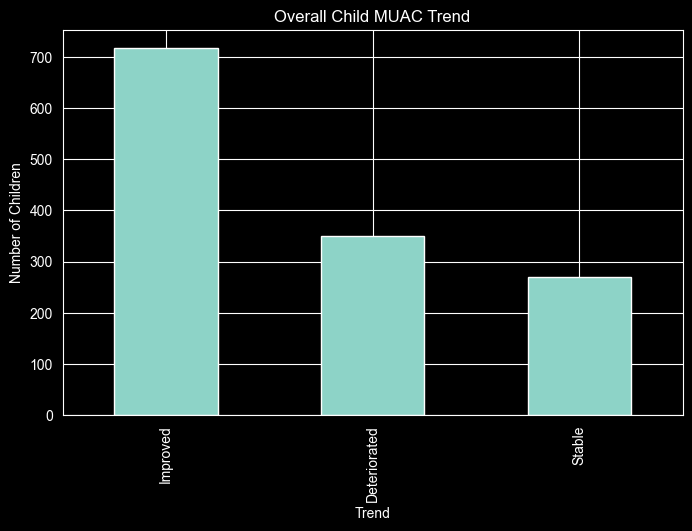

In [12]:
plt.figure(figsize=(8, 5))

trend_counts.plot(kind="bar")

plt.title("Overall Child MUAC Trend")
plt.xlabel("Trend")
plt.ylabel("Number of Children")

plt.show()

## 12. Risk Transition Distribution

In [13]:
risk_transition_counts = trend_summary["Risk_Transition"].value_counts()

risk_transition_counts

Risk_Transition
Same Group               986
Moved to Better Group    234
Moved to Worse Group     116
Name: count, dtype: int64

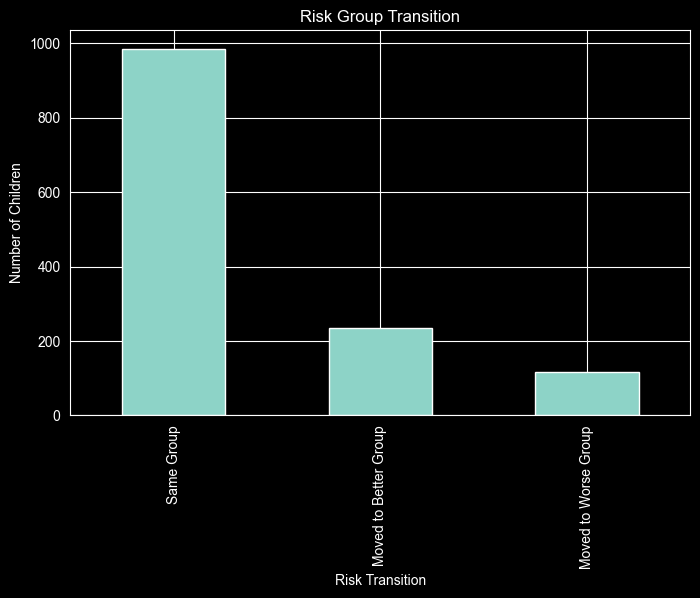

In [14]:
plt.figure(figsize=(8, 5))

risk_transition_counts.plot(kind="bar")

plt.title("Risk Group Transition")
plt.xlabel("Risk Transition")
plt.ylabel("Number of Children")

plt.show()

## 13. Check Individual Child Trend

Use this cell to check any child's full visit history and trend summary.

In [15]:
child_id = "581415010001"

child_history = (
    df[df["ID"] == child_id]
    .sort_values("GmpDate")
)

display(child_history)

child_trend = trend_summary[
    trend_summary["ID"] == child_id
]

display(child_trend)

,ID,GmpDate,Name,DOB,MUAC,Age_Months,Condition,Cluster,Cluster_Name
0,581415010001,2017-12-17,ff,2017-12-17,15.0,0.00,Good,0,Healthy
1,581415010001,2017-12-28,ff,2017-12-17,15.0,0.36,Good,0,Healthy


,ID,Name_First,GmpDate_First,GmpDate_Last,MUAC_First,MUAC_Last,MUAC_Change,MUAC_Change_Percent,Condition_First,Condition_Last,Condition_Transition,Cluster_Name_First,Cluster_Name_Last,Risk_Transition,Trend
0,581415010001,ff,2017-12-17,2017-12-28,15.0,15.0,0.0,0.0,Good,Good,Same Condition,Healthy,Healthy,Same Group,Stable


## 14. Save Trend Analysis Dataset

Two files are saved:

1. trend_analysis.csv: first vs latest visit comparison
2. trend_ready_data.csv: all visits for children with 2+ records

In [16]:
OUTPUT_DIR = Path("../data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

trend_summary_path = OUTPUT_DIR / "trend_analysis.csv"
trend_ready_path = OUTPUT_DIR / "trend_ready_data.csv"

trend_summary.to_csv(trend_summary_path, index=False)
trend_df.to_csv(trend_ready_path, index=False)

print("Trend summary saved:", trend_summary_path)
print("Trend ready data saved:", trend_ready_path)

Trend summary saved: ..\data\trend_analysis.csv
Trend ready data saved: ..\data\trend_ready_data.csv


## 15. Final Summary

In [17]:
final_summary = {
    "Total Records": len(df),
    "Total Children": df["ID"].nunique(),
    "Children with only 1 visit": int((visit_counts == 1).sum()),
    "Children with 2+ visits": int((visit_counts >= 2).sum()),
    "Trend Ready Records": len(trend_df),
    "Trend Ready Children": trend_df["ID"].nunique(),
    "Improved Children": int((trend_summary["Trend"] == "Improved").sum()),
    "Deteriorated Children": int((trend_summary["Trend"] == "Deteriorated").sum()),
    "Stable Children": int((trend_summary["Trend"] == "Stable").sum())
}

final_summary

{'Total Records': 6785,
 'Total Children': 3041,
 'Children with only 1 visit': 1705,
 'Children with 2+ visits': 1336,
 'Trend Ready Records': 5080,
 'Trend Ready Children': 1336,
 'Improved Children': 717,
 'Deteriorated Children': 349,
 'Stable Children': 270}